# Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load

In [2]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\PBI\IDX\Assignment\loan_data_2007_2014.csv")
df

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_7184\63216893.py:1: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\PBI\IDX\Assignment\loan_data_2007_2014.csv")


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,466280,8598660,1440975,18400,18400,18400.0,60 months,14.47,432.64,C,...,NaN,NaN,NaN,NaN,NaN,NaN,29900.0,NaN,NaN,NaN
466281,466281,9684700,11536848,22000,22000,22000.0,60 months,19.97,582.50,D,...,NaN,NaN,NaN,NaN,NaN,NaN,39400.0,NaN,NaN,NaN
466282,466282,9584776,11436914,20700,20700,20700.0,60 months,16.99,514.34,D,...,NaN,NaN,NaN,NaN,NaN,NaN,13100.0,NaN,NaN,NaN
466283,466283,9604874,11457002,2000,2000,2000.0,36 months,7.90,62.59,A,...,NaN,NaN,NaN,NaN,NaN,NaN,53100.0,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

# Dropping Column with 0 data

In [4]:
# Safely drop ONLY completely empty columns, keeping all 466,285 rows intact
df01 = df.dropna(how='all', axis=1)
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 58 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  str    
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  str    
 10  sub_grade                    466285 non-null  str    
 11  emp_title                    438697 non-null  str    
 12  emp_length                   445277 non-null  str    
 13  home_owner

In [5]:
print(df01.shape)  # Should show (466285, updated_column_count)

(466285, 58)


# Missing and duplicate check

In [6]:
#Missing
print("--- Missing Values per Column ---")
print(df01.isnull().sum())

print("\n--- Missing Values Percentage ---")
print((df01.isnull().sum() / len(df)) * 100)

#Duplicate
print("\n--- Duplicate Rows ---")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

# View the actual duplicated rows (optional)
if duplicate_count > 0:
    print(df[df.duplicated(keep=False)])

--- Missing Values per Column ---


Unnamed: 0                          0
id                                  0
member_id                           0
loan_amnt                           0
funded_amnt                         0
funded_amnt_inv                     0
term                                0
int_rate                            0
installment                         0
grade                               0
sub_grade                           0
emp_title                       27588
emp_length                      21008
home_ownership                      0
annual_inc                          4
verification_status                 0
issue_d                             0
loan_status                         0
pymnt_plan                          0
url                                 0
desc                           340304
purpose                             0
title                              21
zip_code                            0
addr_state                          0
dti                                 0
delinq_2yrs 

# Dropping missing withtin 50% threshold

In [7]:
# Select columns where missing values are strictly
df01 = df01.loc[:, df01.isnull().mean() < 0.50]
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 54 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  466285 non-null  int64  
 1   id                          466285 non-null  int64  
 2   member_id                   466285 non-null  int64  
 3   loan_amnt                   466285 non-null  int64  
 4   funded_amnt                 466285 non-null  int64  
 5   funded_amnt_inv             466285 non-null  float64
 6   term                        466285 non-null  str    
 7   int_rate                    466285 non-null  float64
 8   installment                 466285 non-null  float64
 9   grade                       466285 non-null  str    
 10  sub_grade                   466285 non-null  str    
 11  emp_title                   438697 non-null  str    
 12  emp_length                  445277 non-null  str    
 13  home_ownership           

# Dropping Unnecessary Column

In [8]:
df01 = df01.drop(columns=['collection_recovery_fee',
'emp_title',
'grade',
'installment',
'int_rate',
'last_credit_pull_d',
'last_pymnt_amnt',
'next_pymnt_d',
'out_prncp',
'out_prncp_inv',
'recoveries',
'sub_grade',
'tot_coll_amt',
'total_pymnt',
'total_pymnt_inv',
'total_rec_int',
'total_rec_late_fee'])

In [9]:
unnecessary_cols = [
    'id', 
    'member_id',
    'zip_code', 
    'url', 
    'policy_code', 
    'title', 
    'funded_amnt', 
    'funded_amnt_inv', 
    'pymnt_plan',
    'issue_d' # Drop after using it for train/test splitting if needed
]

# Drop unnecessary columns
df01 = df01.drop(columns=unnecessary_cols)

In [10]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 27 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  466285 non-null  int64  
 1   loan_amnt                   466285 non-null  int64  
 2   term                        466285 non-null  str    
 3   emp_length                  445277 non-null  str    
 4   home_ownership              466285 non-null  str    
 5   annual_inc                  466281 non-null  float64
 6   verification_status         466285 non-null  str    
 7   loan_status                 466285 non-null  str    
 8   purpose                     466285 non-null  str    
 9   addr_state                  466285 non-null  str    
 10  dti                         466285 non-null  float64
 11  delinq_2yrs                 466256 non-null  float64
 12  earliest_cr_line            466256 non-null  str    
 13  inq_last_6mths           

In [11]:
#Missing
print("\n--- Missing Values Percentage ---")
print(((df01.isnull().sum() / len(df)) * 100).round(2))


--- Missing Values Percentage ---
Unnamed: 0                     0.00
loan_amnt                      0.00
term                           0.00
emp_length                     4.51
home_ownership                 0.00
annual_inc                     0.00
verification_status            0.00
loan_status                    0.00
purpose                        0.00
addr_state                     0.00
dti                            0.00
delinq_2yrs                    0.01
earliest_cr_line               0.01
inq_last_6mths                 0.01
open_acc                       0.01
pub_rec                        0.01
revol_bal                      0.00
revol_util                     0.07
total_acc                      0.01
initial_list_status            0.00
total_rec_prncp                0.00
last_pymnt_d                   0.08
collections_12_mths_ex_med     0.03
application_type               0.00
acc_now_delinq                 0.01
tot_cur_bal                   15.07
total_rev_hi_lim             

In [12]:
# Convert date columns using format='%b-%y'
date_cols = ['earliest_cr_line', 'last_pymnt_d']

for col in date_cols:
    df01[col] = pd.to_datetime(df01[col], format='%b-%y', errors='coerce')

In [13]:
df01[["delinq_2yrs",
"inq_last_6mths",
"open_acc",
"pub_rec",
"revol_util",
"total_acc",
"collections_12_mths_ex_med",
"acc_now_delinq"
]].sample(5)

,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,collections_12_mths_ex_med,acc_now_delinq
267539,0.0,1.0,18.0,0.0,28.3,25.0,0.0,0.0
315555,2.0,0.0,8.0,0.0,47.4,34.0,0.0,0.0
403198,1.0,2.0,9.0,0.0,51.0,23.0,0.0,0.0
193421,0.0,0.0,5.0,0.0,71.2,5.0,0.0,0.0
193769,0.0,0.0,9.0,0.0,49.8,18.0,0.0,0.0


In [14]:
df01["earliest_cr_line"].value_counts(dropna=False)

earliest_cr_line
2000-10-01    3674
2000-08-01    3597
2001-08-01    3455
1999-10-01    3406
2001-10-01    3329
              ... 
2061-07-01       1
2058-05-01       1
2053-01-01       1
2050-05-01       1
2056-11-01       1
Name: count, Length: 665, dtype: int64

# Droping Posible Data Leakage

In [15]:
# List of data leakage columns to remove
leakage_cols = [
    'last_pymnt_d', 
    'collections_12_mths_ex_med', 
    'acc_now_delinq', 
    'tot_cur_bal', 
    'total_rev_hi_lim',
    'total_rec_prncp'
]

# Drop leakage columns from your ML dataset
df01 = df01.drop(columns=leakage_cols)

In [16]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Unnamed: 0           466285 non-null  int64         
 1   loan_amnt            466285 non-null  int64         
 2   term                 466285 non-null  str           
 3   emp_length           445277 non-null  str           
 4   home_ownership       466285 non-null  str           
 5   annual_inc           466281 non-null  float64       
 6   verification_status  466285 non-null  str           
 7   loan_status          466285 non-null  str           
 8   purpose              466285 non-null  str           
 9   addr_state           466285 non-null  str           
 10  dti                  466285 non-null  float64       
 11  delinq_2yrs          466256 non-null  float64       
 12  earliest_cr_line     466256 non-null  datetime64[us]
 13  inq_last_6mths       4662

# Dropping Anomaly

## Earliest_cr_line

In [17]:
# Output format: Year-Month
df01['earliest_cr_line'] = pd.to_datetime(df01['earliest_cr_line']).dt.to_period('M')

In [18]:
df01['earliest_cr_line'].info()

<class 'pandas.Series'>
RangeIndex: 466285 entries, 0 to 466284
Series name: earliest_cr_line
Non-Null Count   Dtype    
--------------   -----    
466256 non-null  period[M]
dtypes: period[M](1)
memory usage: 3.6 MB


In [19]:
# Filtering
df01 = df01[df01['earliest_cr_line'] <= '2026-08']

In [20]:
print("Latest date remaining:", df01['earliest_cr_line'].max())

Latest date remaining: 2011-11


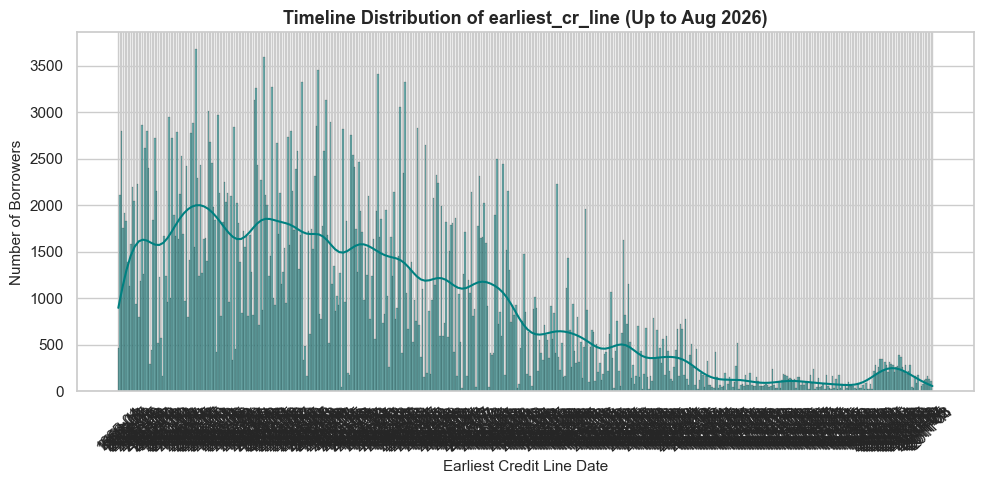

In [21]:
#Create the timeline distribution plot
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

data01 = df01[df01["earliest_cr_line"] <= "2026-08"].copy()
data01["earliest_cr_line"] = data01["earliest_cr_line"].astype(str)

ax = sns.histplot(
    data=data01,
    x="earliest_cr_line",
    bins=40,
    color="teal",
    edgecolor="black",
    kde=True,
)

#Styling and Formatting
plt.title(
    "Timeline Distribution of earliest_cr_line (Up to Aug 2026)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Earliest Credit Line Date", fontsize=11)
plt.ylabel("Number of Borrowers", fontsize=11)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Pub_Rec

In [22]:
df01["pub_rec"].value_counts(dropna=False)

pub_rec
0.0     404011
1.0      52807
2.0       5599
3.0       1606
4.0        517
5.0        272
6.0        134
7.0         62
8.0         27
9.0         16
10.0        13
11.0         7
12.0         2
13.0         2
49.0         1
54.0         1
19.0         1
16.0         1
15.0         1
14.0         1
18.0         1
40.0         1
63.0         1
21.0         1
34.0         1
17.0         1
Name: count, dtype: int64

# Missing Re-Check

In [23]:
#Missing
print("\n--- Missing Values Percentage ---")
print((df01.isnull().sum() / len(df)) * 100)


--- Missing Values Percentage ---
Unnamed: 0             0.000000
loan_amnt              0.000000
term                   0.000000
emp_length             4.413181
home_ownership         0.000000
annual_inc             0.000000
verification_status    0.000000
loan_status            0.000000
purpose                0.000000
addr_state             0.000000
dti                    0.000000
delinq_2yrs            0.000000
earliest_cr_line       0.000000
inq_last_6mths         0.000000
open_acc               0.000000
pub_rec                0.000000
revol_bal              0.000000
revol_util             0.066697
total_acc              0.000000
initial_list_status    0.000000
application_type       0.000000
dtype: float64


## Missing Handling

### emp_length

In [24]:
df01["emp_length"] = df01["emp_length"].fillna("Unknown")

### revol_util

In [25]:
df01 = df01.dropna(subset=["revol_util"])

# Feature Engineering

In [26]:
df01.info()

<class 'pandas.DataFrame'>
Index: 464776 entries, 0 to 466284
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   Unnamed: 0           464776 non-null  int64    
 1   loan_amnt            464776 non-null  int64    
 2   term                 464776 non-null  str      
 3   emp_length           464776 non-null  str      
 4   home_ownership       464776 non-null  str      
 5   annual_inc           464776 non-null  float64  
 6   verification_status  464776 non-null  str      
 7   loan_status          464776 non-null  str      
 8   purpose              464776 non-null  str      
 9   addr_state           464776 non-null  str      
 10  dti                  464776 non-null  float64  
 11  delinq_2yrs          464776 non-null  float64  
 12  earliest_cr_line     464776 non-null  period[M]
 13  inq_last_6mths       464776 non-null  float64  
 14  open_acc             464776 non-null  float64  
 15 

In [27]:
dfml = df01.copy()

# 1. Credit History Length (Years)
if "issue_d" in dfml.columns:
    dfml["issue_d_dt"] = pd.to_datetime(
        dfml["issue_d"], format="%b-%y", errors="coerce"
    )
    dfml["earliest_cr_line_dt"] = pd.to_datetime(
        dfml["earliest_cr_line"], format="%b-%y", errors="coerce"
    )

    dfml["credit_age_years"] = (
        dfml["issue_d_dt"] - dfml["earliest_cr_line_dt"]
    ).dt.days / 365.25

    # Clean up temporary datetime helper columns
    dfml.drop(
        columns=["issue_d_dt", "earliest_cr_line_dt"], inplace=True
    )

In [28]:
# 2. Income & Debt Capacity Ratios
dfml["loan_to_income"] = dfml["loan_amnt"] / (
    dfml["annual_inc"] + 1
)
dfml["monthly_income"] = dfml["annual_inc"] / 12

In [29]:
# 3. Revolving Credit Metrics
# Back-calculate total estimated revolving limit from utilization and balance
dfml["est_revol_limit"] = dfml["revol_bal"] / (
    (dfml["revol_util"] / 100) + 0.001
)
dfml["revol_bal_per_open_acc"] = dfml["revol_bal"] / (
    dfml["open_acc"] + 1
)

In [30]:
# 4. Account Activity & Inquiry Ratios
dfml["open_to_total_acc_ratio"] = dfml["open_acc"] / (
    dfml["total_acc"] + 1
)
dfml["inq_per_open_acc"] = dfml["inq_last_6mths"] / (
    dfml["open_acc"] + 1
)

In [31]:
# 5. Risk Indicator Flags (Binary Signals)
dfml["has_pub_rec"] = (dfml["pub_rec"] > 0).astype(int)
dfml["has_delinq_2yrs"] = (dfml["delinq_2yrs"] > 0).astype(
    int
)
dfml["has_inq_6mths"] = (
    dfml["inq_last_6mths"] > 0
).astype(int)

In [32]:
# Check the new features
print(
    f"Original columns: {df01.shape[1]} | New DataFrame columns: {dfml.shape[1]}"
)
dfml.head()

Original columns: 21 | New DataFrame columns: 30


,Unnamed: 0,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,...,application_type,loan_to_income,monthly_income,est_revol_limit,revol_bal_per_open_acc,open_to_total_acc_ratio,inq_per_open_acc,has_pub_rec,has_delinq_2yrs,has_inq_6mths
0,0,5000,36 months,10+ years,RENT,24000.0,Verified,Fully Paid,credit_card,AZ,...,INDIVIDUAL,0.208325,2000.000000,16286.396181,3412.000000,0.300000,0.250000,0,0,1
1,1,2500,60 months,< 1 year,RENT,30000.0,Source Verified,Charged Off,car,GA,...,INDIVIDUAL,0.083331,2500.000000,17757.894737,421.750000,0.600000,1.250000,0,0,1
2,2,2400,36 months,10+ years,RENT,12252.0,Not Verified,Fully Paid,small_business,IL,...,INDIVIDUAL,0.195870,1021.000000,2997.971602,985.333333,0.181818,0.666667,0,0,1
3,3,10000,36 months,10+ years,RENT,49200.0,Source Verified,Fully Paid,other,CA,...,INDIVIDUAL,0.203248,4100.000000,26530.805687,508.909091,0.263158,0.090909,0,0,1
4,4,3000,60 months,1 year,RENT,80000.0,Source Verified,Current,other,OR,...,INDIVIDUAL,0.037500,6666.666667,51450.000000,1736.437500,0.384615,0.000000,0,0,0


In [33]:
dfml = dfml.drop(columns=["Unnamed: 0"])

In [34]:
dfml.info()

<class 'pandas.DataFrame'>
Index: 464776 entries, 0 to 466284
Data columns (total 29 columns):
 #   Column                   Non-Null Count   Dtype    
---  ------                   --------------   -----    
 0   loan_amnt                464776 non-null  int64    
 1   term                     464776 non-null  str      
 2   emp_length               464776 non-null  str      
 3   home_ownership           464776 non-null  str      
 4   annual_inc               464776 non-null  float64  
 5   verification_status      464776 non-null  str      
 6   loan_status              464776 non-null  str      
 7   purpose                  464776 non-null  str      
 8   addr_state               464776 non-null  str      
 9   dti                      464776 non-null  float64  
 10  delinq_2yrs              464776 non-null  float64  
 11  earliest_cr_line         464776 non-null  period[M]
 12  inq_last_6mths           464776 non-null  float64  
 13  open_acc                 464776 non-null  flo

In [35]:
dfml

,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,...,application_type,loan_to_income,monthly_income,est_revol_limit,revol_bal_per_open_acc,open_to_total_acc_ratio,inq_per_open_acc,has_pub_rec,has_delinq_2yrs,has_inq_6mths
0,5000,36 months,10+ years,RENT,24000.0,Verified,Fully Paid,credit_card,AZ,27.65,...,INDIVIDUAL,0.208325,2000.000000,16286.396181,3412.000000,0.300000,0.250000,0,0,1
1,2500,60 months,< 1 year,RENT,30000.0,Source Verified,Charged Off,car,GA,1.00,...,INDIVIDUAL,0.083331,2500.000000,17757.894737,421.750000,0.600000,1.250000,0,0,1
2,2400,36 months,10+ years,RENT,12252.0,Not Verified,Fully Paid,small_business,IL,8.72,...,INDIVIDUAL,0.195870,1021.000000,2997.971602,985.333333,0.181818,0.666667,0,0,1
3,10000,36 months,10+ years,RENT,49200.0,Source Verified,Fully Paid,other,CA,20.00,...,INDIVIDUAL,0.203248,4100.000000,26530.805687,508.909091,0.263158,0.090909,0,0,1
4,3000,60 months,1 year,RENT,80000.0,Source Verified,Current,other,OR,17.94,...,INDIVIDUAL,0.037500,6666.666667,51450.000000,1736.437500,0.384615,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466280,18400,60 months,4 years,MORTGAGE,110000.0,Source Verified,Current,debt_consolidation,TX,19.85,...,INDIVIDUAL,0.167271,9166.666667,29868.725869,1221.473684,0.486486,0.105263,0,0,1
466281,22000,60 months,10+ years,MORTGAGE,78000.0,Verified,Charged Off,debt_consolidation,TN,18.45,...,INDIVIDUAL,0.282048,6500.000000,39306.034483,959.894737,0.580645,0.263158,1,0,1
466282,20700,60 months,7 years,MORTGAGE,46000.0,Verified,Current,debt_consolidation,OH,25.65,...,INDIVIDUAL,0.449990,3833.333333,13062.500000,352.000000,0.409091,0.105263,0,0,1
466283,2000,36 months,3 years,OWN,83000.0,Verified,Fully Paid,credit_card,CA,5.39,...,INDIVIDUAL,0.024096,6916.666667,52796.296296,518.363636,0.750000,0.045455,0,1,1


# Changing target into boolean (1/0)

In [36]:
dfml['loan_status'].value_counts()

loan_status
Current                                                223471
Fully Paid                                             184240
Charged Off                                             42300
Late (31-120 days)                                       6880
In Grace Period                                          3142
Does not meet the credit policy. Status:Fully Paid       1949
Late (16-30 days)                                        1212
Default                                                   828
Does not meet the credit policy. Status:Charged Off       754
Name: count, dtype: int64

In [37]:
# 1. Define lists for target mapping
bad_statuses = [
    "Charged Off",
    "Late (31-120 days)",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
]

good_statuses = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
]

# 2. Filter dfml to keep only completed loans
df_model = dfml[
    dfml["loan_status"].isin(bad_statuses + good_statuses)
].copy()

# 3. (1 = Bad / Default, 0 = Good / Fully Paid)
df_model["target"] = df_model["loan_status"].isin(bad_statuses).astype(int)

# 4. Drop the original loan_status column
df_model.drop(columns=["loan_status"], inplace=True)

# Check class distribution
print(df_model["target"].value_counts(normalize=True))

target
0    0.78577
1    0.21423
Name: proportion, dtype: float64


# Seperating Feature Target

In [38]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

# Split

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (189560, 28) | Test shape: (47391, 28)


# Categorical Encoding

## Ordinal Mapping

In [40]:
emp_mapping = {
    "Unknown": -1,
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10,
}

X_train["emp_length"] = X_train["emp_length"].map(emp_mapping).fillna(-1)
X_test["emp_length"] = X_test["emp_length"].map(emp_mapping).fillna(-1)

## One-Hot Encoding for Nominal

In [41]:
# Identify non-numeric columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# One-Hot Encode
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Align columns to ensure Train and Test have identical features
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_7184\2845841297.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()


# Baseline Model

In [42]:
# Droppin Issue_d and Earliest_cr_line credit_age_years
date_cols_to_drop = ["issue_d", "earliest_cr_line"]

X_train.drop(
    columns=[c for c in date_cols_to_drop if c in X_train.columns],
    inplace=True,
)
X_test.drop(
    columns=[c for c in date_cols_to_drop if c in X_test.columns], inplace=True
)

In [43]:
from xgboost import XGBClassifier

# Calculate class weight ratio for imbalance handling (~186k / 50k ≈ 3.66)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,  # Handles class imbalance
    random_state=42,
    eval_metric="auc",
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## Model Evaluation

In [44]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict probabilities for the positive class (Default = 1)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 1. ROC-AUC Score
auc_score = roc_auc_score(y_test, y_pred_proba)

# 2. Gini Coefficient (Standard in Credit Risk)
gini_score = 2 * auc_score - 1

print(f"ROC-AUC Score: {auc_score:.2f}")
print(f"Gini Coefficient: {gini_score:.2f}")

ROC-AUC Score: 0.70
Gini Coefficient: 0.40


### Fine Tuning

In [45]:
import numpy as np
from sklearn.metrics import classification_report

# Evaluate precision/recall at different decision thresholds (e.g., 0.20 to 0.40)
custom_threshold = 0.40
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(
    classification_report(
        y_test, y_pred_custom, target_names=["Good (0)", "Bad (1)"]
    )
)

              precision    recall  f1-score   support

    Good (0)       0.90      0.43      0.58     37238
     Bad (1)       0.28      0.82      0.42     10153

    accuracy                           0.51     47391
   macro avg       0.59      0.63      0.50     47391
weighted avg       0.77      0.51      0.55     47391



# Catboost

In [46]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

In [47]:
#TARGET MAPPING & LEAKAGE CLEANUP
bad_statuses = [
    "Charged Off",
    "Late (31-120 days)",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
]

good_statuses = [
    "Fully Paid",
    "Does not meet the credit policy. Status:Fully Paid",
]

# Filter out ongoing loans (Current, Grace Period, etc.)
df_model = dfml[
    dfml["loan_status"].isin(bad_statuses + good_statuses)
].copy()

# Create binary target (1 = Default/Bad, 0 = Good)
df_model["target"] = df_model["loan_status"].isin(bad_statuses).astype(int)

# Drop raw status and target leakage columns
leakage_cols = ["loan_status", "total_rec_prncp", "Unnamed: 0"]
df_model.drop(
    columns=[c for c in leakage_cols if c in df_model.columns], inplace=True
)

In [48]:
#SEPARATE FEATURES & TRAIN/TEST SPLIT
X = df_model.drop(columns=["target"])
y = df_model["target"]

# Drop raw date/period columns (using engineered features instead)
date_cols = ["issue_d", "earliest_cr_line"]
X.drop(columns=[c for c in date_cols if c in X.columns], inplace=True)

# Stratified split to maintain ~21.4% default distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [49]:
#CATEGORICAL FEATURE HANDLING
# Identify all object/categorical columns
cat_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Ensure missing categorical values are treated as a distinct string class
for col in cat_features:
    X_train[col] = X_train[col].fillna("Unknown").astype(str)
    X_test[col] = X_test[col].fillna("Unknown").astype(str)

print(f"Dataset Shape - Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Categorical Features ({len(cat_features)}): {cat_features}")

Dataset Shape - Train: (189560, 27) | Test: (47391, 27)
Categorical Features (8): ['term', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type']


C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_7184\3935576293.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X_train.select_dtypes(


In [50]:
# STEP 4: MODEL INITIALIZATION & TRAINING

cb_model = CatBoostClassifier(
    iterations=600,
    learning_rate=0.04,
    depth=6,
    eval_metric="AUC",
    auto_class_weights="Balanced",  # Re-weights for 78.5 / 21.5 target ratio
    random_seed=42,
    verbose=100,
)

# Reassign model object during fit to preserve trained parameters
cb_model = cb_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
)

0:	test: 0.6622648	best: 0.6622648 (0)	total: 280ms	remaining: 2m 47s
100:	test: 0.6951774	best: 0.6951774 (100)	total: 13.7s	remaining: 1m 7s
200:	test: 0.6992291	best: 0.6992291 (200)	total: 26.7s	remaining: 53.1s
300:	test: 0.7010857	best: 0.7010857 (300)	total: 39.5s	remaining: 39.3s
400:	test: 0.7026923	best: 0.7026923 (400)	total: 53.1s	remaining: 26.3s
500:	test: 0.7035599	best: 0.7035599 (500)	total: 1m 6s	remaining: 13.2s
599:	test: 0.7039511	best: 0.7039511 (599)	total: 1m 19s	remaining: 0us

bestTest = 0.7039511464
bestIteration = 599



In [51]:
#EVALUATION & THRESHOLD SWEEP

# Extract default probabilities
y_pred_proba = cb_model.predict_proba(X_test)[:, 1]

# Overall Discrimination Metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
gini_score = 2 * auc_score - 1

print("\n" + "=" * 45)
print(f"CatBoost Test ROC-AUC Score : {auc_score:.4f}")
print(f"CatBoost Test Gini Score    : {gini_score:.4f}")
print("=" * 45)

# Decision Cut-off Sweep for Business Tuning
print("\n--- Decision Threshold Evaluation ---")
for threshold in [0.45, 0.50, 0.55, 0.60]:
    y_pred_custom = (y_pred_proba >= threshold).astype(int)
    print(f"\n[ Threshold = {threshold} ]")
    print(
        classification_report(
            y_test, y_pred_custom, target_names=["Good (0)", "Bad (1)"]
        )
    )


CatBoost Test ROC-AUC Score : 0.7040
CatBoost Test Gini Score    : 0.4079

--- Decision Threshold Evaluation ---

[ Threshold = 0.45 ]
              precision    recall  f1-score   support

    Good (0)       0.89      0.55      0.68     37238
     Bad (1)       0.31      0.74      0.44     10153

    accuracy                           0.59     47391
   macro avg       0.60      0.64      0.56     47391
weighted avg       0.76      0.59      0.63     47391


[ Threshold = 0.5 ]
              precision    recall  f1-score   support

    Good (0)       0.87      0.66      0.75     37238
     Bad (1)       0.34      0.64      0.44     10153

    accuracy                           0.65     47391
   macro avg       0.60      0.65      0.59     47391
weighted avg       0.75      0.65      0.68     47391


[ Threshold = 0.55 ]
              precision    recall  f1-score   support

    Good (0)       0.85      0.75      0.80     37238
     Bad (1)       0.37      0.53      0.43     10153

   

## Feature Importance

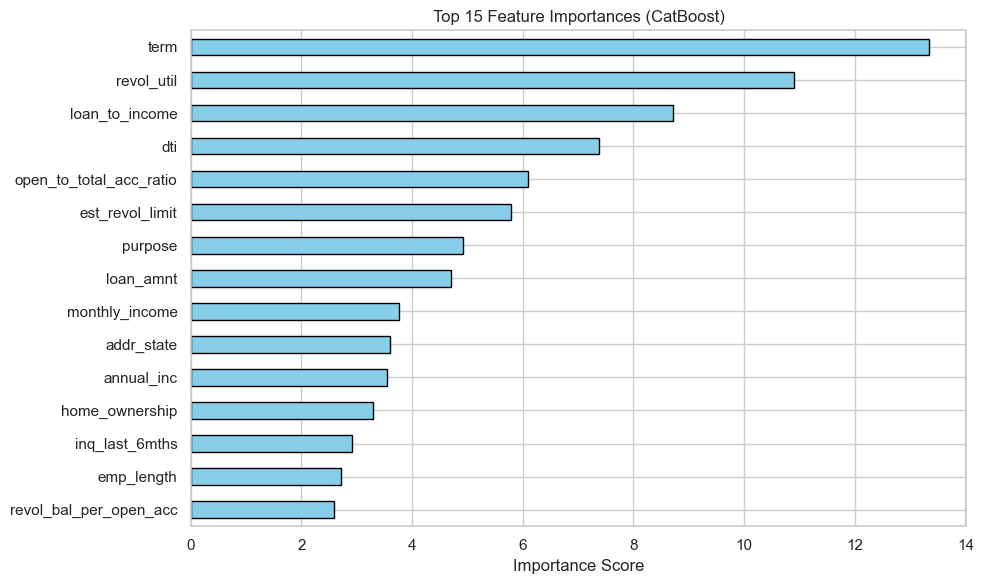

Top 10 Drivers of Default Risk:
term                       13.343510
revol_util                 10.906787
loan_to_income              8.714985
dti                         7.384789
open_to_total_acc_ratio     6.089316
est_revol_limit             5.784923
purpose                     4.920004
loan_amnt                   4.694409
monthly_income              3.763626
addr_state                  3.592608
dtype: float64


In [52]:
# Extract and format feature importances
feature_imp = pd.Series(
    cb_model.get_feature_importance(), index=X_train.columns
).sort_values(ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
feature_imp.head(15).plot(
    kind="barh", color="skyblue", edgecolor="black"
).invert_yaxis()
plt.title("Top 15 Feature Importances (CatBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top 10 Drivers of Default Risk:")
print(feature_imp.head(10))

## Fine Tuning

In [53]:
import optuna

# Silence default Optuna output logs for a cleaner console
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "iterations": 800,
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.08, log=True
        ),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "eval_metric": "AUC",
        "auto_class_weights": "Balanced",
        "random_seed": 42,
        "verbose": False,
    }

    model = CatBoostClassifier(**params)
    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_test, y_test),
        early_stopping_rounds=50,
    )

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_pred_proba)

c:\Users\arya wardhana\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Optimization

In [54]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, show_progress_bar=True)

print("=" * 50)
print(f"Best Test ROC-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  '{key}': {value}")
print("=" * 50)

Best trial: 21. Best value: 0.704663: 100%|██████████| 25/25 [37:43<00:00, 90.55s/it] 

Best Test ROC-AUC Score: 0.7047
Best Hyperparameters:
  'learning_rate': 0.04833296533797083
  'depth': 5
  'l2_leaf_reg': 9.752111570982535
  'random_strength': 0.00220093652826492
  'bagging_temperature': 0.23462812268863875
  'border_count': 210


### Train

In [55]:
# Best parameters from Optuna search
best_params = {
    "iterations": 1000,
    "learning_rate": 0.04833296533797083,
    "depth": 5,
    "l2_leaf_reg": 9.752111570982535,
    "random_strength": 0.00220093652826492,
    "bagging_temperature": 0.23462812268863875,
    "border_count": 210,
    "eval_metric": "AUC",
    "auto_class_weights": "Balanced",
    "random_seed": 42,
    "verbose": 100,
}

# Train final CatBoost model
final_cb_model = CatBoostClassifier(**best_params)
final_cb_model = final_cb_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50,
)

# Predict probabilities
y_pred_proba_final = final_cb_model.predict_proba(X_test)[:, 1]
print(
    f"\nFinal ROC-AUC: {roc_auc_score(y_test, y_pred_proba_final):.4f} | Gini: {2 * roc_auc_score(y_test, y_pred_proba_final) - 1:.4f}"
)

0:	test: 0.6593600	best: 0.6593600 (0)	total: 158ms	remaining: 2m 37s
100:	test: 0.6963175	best: 0.6963175 (100)	total: 11.2s	remaining: 1m 39s
200:	test: 0.7004101	best: 0.7004101 (200)	total: 23.2s	remaining: 1m 32s
300:	test: 0.7023143	best: 0.7023344 (299)	total: 33.9s	remaining: 1m 18s
400:	test: 0.7033801	best: 0.7033801 (400)	total: 45.4s	remaining: 1m 7s
500:	test: 0.7039578	best: 0.7039588 (499)	total: 58.3s	remaining: 58.1s
600:	test: 0.7043079	best: 0.7043079 (600)	total: 1m 9s	remaining: 45.9s
700:	test: 0.7044947	best: 0.7044947 (700)	total: 1m 20s	remaining: 34.1s
800:	test: 0.7046361	best: 0.7046630 (758)	total: 1m 30s	remaining: 22.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7046629741
bestIteration = 758

Shrink model to first 759 iterations.

Final ROC-AUC: 0.7047 | Gini: 0.4093
